In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

In [3]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", temperature=0.5 
)

In [6]:
class Sentiment(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description="The sentiment of the review. It can be either negative or positive") 


structure_llm = llm.with_structured_output(Sentiment)

In [21]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Quality", "Price", "Other"] = Field(description="The issue type of the review")
    tone: Literal["angry", "frustrated", "disappointed", "calm", "Other"] = Field(description="The emotional tone of the review")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgent or critical the issue is")


diagnosis_llm = llm.with_structured_output(DiagnosisSchema)

In [20]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    reply: str

    diagnosis: dict



In [24]:
def get_sentiment(state: ReviewState):
    review = state['review']

    prompt = f"Analyze the review and find the sentiment of the review. Return the sentiment it can be either positive or negative. Here's the review in ''' delimeters. \n '''{review}'''"

    res = structure_llm.invoke(prompt)

    return {'sentiment': res.sentiment}

def check_sentiment(state: ReviewState) -> Literal['get_positive_reply', 'run_diagnosis']:
    sentiment = state['sentiment']

    return 'run_diagnosis' if sentiment == 'negative' else 'get_positive_reply'

def run_diagnosis(state: ReviewState):
    review = state['review']

    prompt = f"Diagnose this negative review in ''' delimeters '''{review}'''. \n Return issue_type, tone, and urgency"
    res = diagnosis_llm.invoke(prompt)
    # model_dump -> convert json response to dictionary
    return {'diagnosis': res.model_dump()}


def get_positive_reply(state: ReviewState):
    review = state['review']

    prompt = f"Generate an appropriate reply for the following product review in ''' delimeters '''{review}'''. \n Keep the reply under 30 words"
    res = llm.invoke(prompt).content

    return {'reply': res}

def get_negative_reply(state: ReviewState):

    review = state['review']
    diagnosis = state['diagnosis']

    prompt = f"You are a support assistent. The user had a {diagnosis['issue_type']} issue, sounded {diagnosis['tone']} and marked urgency as {diagnosis['urgency']}  Write an empathetic, helpful resolution reply for the following review in ''' delimeters '''{review}'''. \n Keep the reply under 30 words "
    res = llm.invoke(prompt).content

    return {'reply': res}

In [25]:
graph = StateGraph(ReviewState)
graph.add_node('get_sentiment', get_sentiment)
graph.add_node('get_positive_reply', get_positive_reply)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('get_negative_reply', get_negative_reply)

graph.add_edge(START, 'get_sentiment')
graph.add_conditional_edges('get_sentiment', check_sentiment)

graph.add_edge('get_positive_reply', END)
graph.add_edge('run_diagnosis', 'get_negative_reply')
graph.add_edge('get_negative_reply', END)

workflow = graph.compile()

In [26]:
initial_state = {
    "review": """
I had high hopes for this watch, but it failed to deliver. Within just two weeks of light wear, the glass face developed noticeable scratches, and the strap showed early signs of fraying. Worse yet, the timekeeping is unreliable—it loses several minutes every few days, requiring constant readjustment. The crown feels loose and cheap, and the watch is far too light and hollow on the wrist to justify its price. Overall, a poorly made timepiece that falls well short of expectations.
     """
}

final_state = workflow.invoke(initial_state)

In [29]:
final_state['sentiment']
final_state['reply']
final_state['diagnosis']

{'issue_type': 'Quality', 'tone': 'disappointed', 'urgency': 'high'}

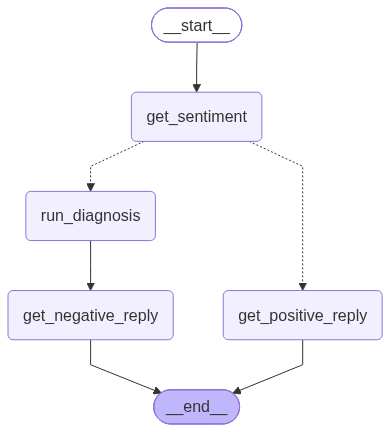

In [30]:

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())